# Image Augmentation for Tropical Coastal Monitoring
**Student Name:** Andrés Jauch  
**Semester Term:** FS26  

## Introduction & Use Case
For this challenge, I am using a NASA MODIS satellite image of Hispaniola (the Dominican Republic and Haiti). I wanted to focus on coastal monitoring because areas like Punta Cana are super dependent on tourism, and tracking coastal erosion or changes in the water is really important for them.

The big issue here is tropical weather. You get a lot of humidity, haze, and clouds, which blurs the satellite photos and ruins the contrast. If the contrast is bad, standard edge detection or segmentation won't work well because the transition from land to water gets washed out.

My goal in this first notebook is to simulate this tropical haze and see how much it actually ruins the sharpness of the image. I'll set up a clean baseline image and then apply two different levels of haze to see what happens.

### Data
- Visual target:  Coastlines and shallow water transitions.

* **Source:** NASA MODIS Web Gallery. (2016, February 7). *Haiti and Dominican Republic*. 
Downloaded from [https://modis.gsfc.nasa.gov/gallery/individual.php?db_date=2016-02-07](https://modis.gsfc.nasa.gov/gallery/individual.php?db_date=2016-02-07)

## Methodology & Experimental Design
To simulate the tropical weather, I'm using two main image augmentations:

1. **Gaussian Blur:** This simulates light scattering through humidity or thin clouds. It smooths out the details. I'll use the kernel size (k) to control this. The kernel size has to be an odd number, like 5 or 11, and a bigger kernel means more blur.
2. **Contrast Adjustment:** This simulates the white haze effect. I'll reduce the contrast by scaling the pixel values down (using alpha, like 0.8 or 0.5) and then add some brightness offset (beta) so the image looks washed out and milky.

I will compare three setups:
- **Baseline:** The original clean satellite image.
- **Config 1 (Light Haze):** A mild blur (kernel k = 5) and moderate contrast reduction (alpha = 0.8).
- **Config 2 (Heavy Haze):** Stronger blur (kernel k = 11) and severe contrast reduction (alpha = 0.5).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

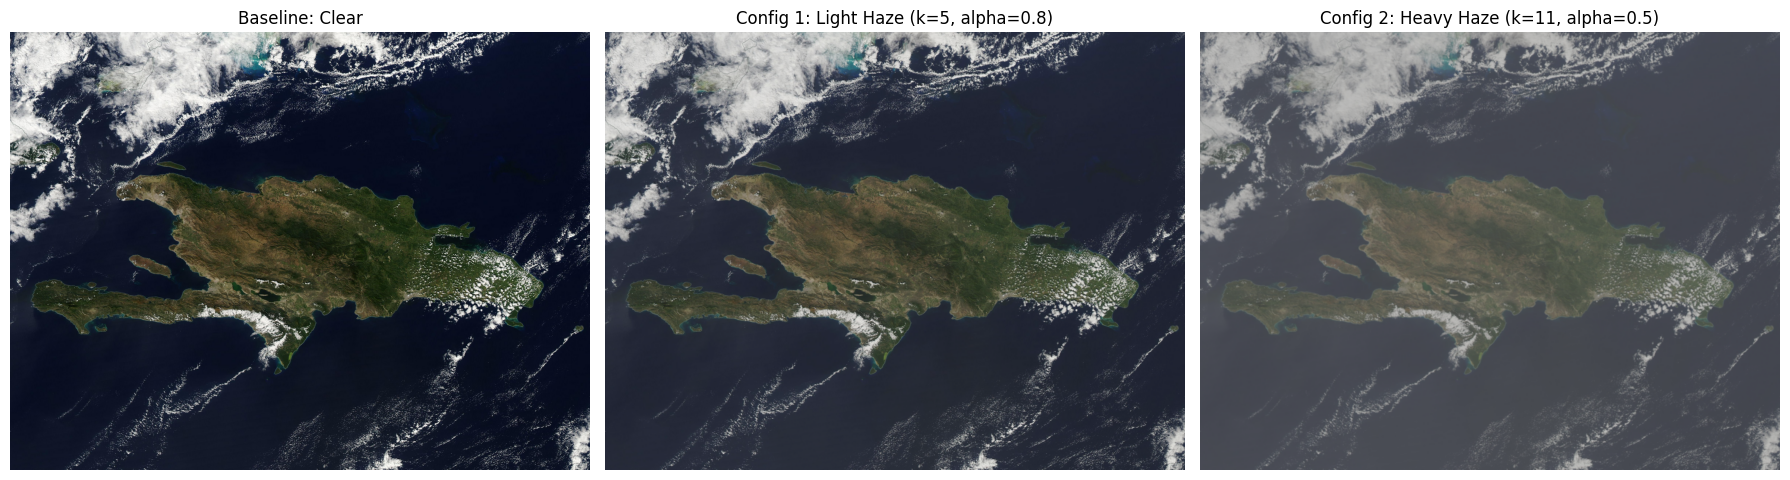

In [ ]:
# Load the satellite image and convert to RGB
img_source = cv2.imread("source/satelita_hispaniola.jpg")
if img_source is None:
    raise FileNotFoundError("Error: Couldnt load ../source/satelita_hispaniola.jpg")

img_rgb = cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB)

# Function to simulate haze using blur and contrast scale
def simulate_tropical_haze(image, kernel_size, alpha):
    blurred = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    # Scale contrast and offset brightness to get the washed-out white haze look
    beta = (1.0 - alpha) * 255 / 2
    hazy = cv2.convertScaleAbs(blurred, alpha=alpha, beta=beta)
    return hazy

# Generate the different configurations
img_baseline = img_rgb.copy()
img_config1 = simulate_tropical_haze(img_rgb, kernel_size=5, alpha=0.8)
img_config2 = simulate_tropical_haze(img_rgb, kernel_size=11, alpha=0.5)

# Plotting the three cases side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_baseline)
axes[0].set_title('Baseline: Clear')
axes[0].axis('off')

axes[1].imshow(img_config1)
axes[1].set_title('Config 1: Light Haze (k=5, alpha=0.8)')
axes[1].axis('off')

axes[2].imshow(img_config2)
axes[2].set_title('Config 2: Heavy Haze (k=11, alpha=0.5)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Evaluation & Metrics
For evaluating the image quality, I will use exactly one metric: Sharpness, calculated as the **Variance of the Laplacian**.

The Laplacian operator works like a second derivative that highlights regions of rapid intensity change, which are the edges. By calculating the variance of this response, we get a single number representing how much high-frequency detail is in the image.

If an image is sharp and has clear coastlines, the Laplacian variance will be high. If it is blurred or washed out by haze, the edges get smoothed out and the variance drops. This is a good metric for my task because I want to see how much the coastline boundary details are degraded by the haze.

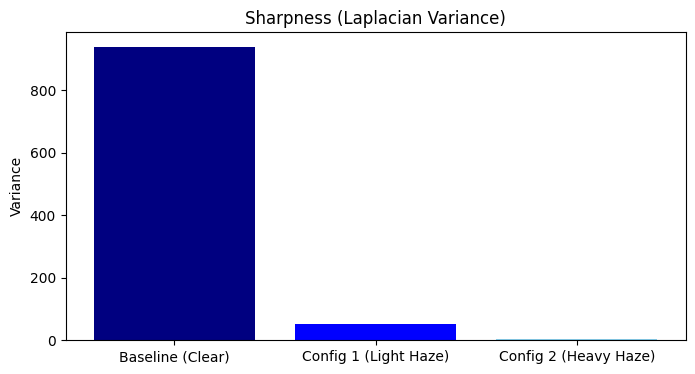

,Configuration,Sharpness (Laplacian Var),Relative Change (%)
0,Baseline (Clear),937.880546,0.000000
1,Config 1 (Light Haze),52.820938,-94.368053
2,Config 2 (Heavy Haze),3.040603,-99.675801


In [3]:
def calculate_sharpness(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

sharp_base = calculate_sharpness(img_baseline)
sharp_c1 = calculate_sharpness(img_config1)
sharp_c2 = calculate_sharpness(img_config2)

# Save results in a dataframe
data = {
    'Configuration': ['Baseline (Clear)', 'Config 1 (Light Haze)', 'Config 2 (Heavy Haze)'],
    'Sharpness (Laplacian Var)': [sharp_base, sharp_c1, sharp_c2],
    'Relative Change (%)': [0.0, (sharp_c1 - sharp_base)/sharp_base * 100, (sharp_c2 - sharp_base)/sharp_base * 100]
}
df_metrics = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(8, 4))
plt.bar(df_metrics['Configuration'], df_metrics['Sharpness (Laplacian Var)'], color=['navy', 'blue', 'skyblue'])
plt.title('Sharpness (Laplacian Variance)')
plt.ylabel('Variance')
plt.show()

display(df_metrics)

## Discussion & Conclusion
Looking at the results, the sharpness drops extremely fast when haze is added. The baseline sharpness starts at 937.88. In Config 1 (light haze), it drops by 94.37% down to 52.82. In Config 2 (heavy haze), it completely collapses, dropping by 99.68% down to only 3.04.

This makes sense because the Gaussian blur removes the fine details and edges, while the contrast reduction makes everything look greyish and flat. When the histogram is compressed, the transition between the island and the sea becomes very gradual instead of sharp.

A limitation of my setup is that it applies the haze globally across the image. In real life, Caribbean weather is "patchy", you would have clouds and haze in some areas, while other parts of the island remain clear. Also, Laplacian variance only measures edge intensity changes, not color differences. But this is still a good worst-case scenario test. If my edge detection or segmentation works on these hazy simulations, it should be robust enough for real-world images too.